In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlran-aekam/MLRan_X_test_RFE.csv
/kaggle/input/mlran-aekam/mlran_dataset_metadata.csv
/kaggle/input/mlran-aekam/MLRan_X_train_RFE.csv
/kaggle/input/mlran-aekam/MLRan_labels.csv
/kaggle/input/mlran-aekam/type_test_sampleids.csv
/kaggle/input/mlran-aekam/type_train_sampleids.csv
/kaggle/input/mlran-aekam/RFE_selected_feature_names_dic.json


In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 104.2 MB/s eta 0:00:00


Starting Optimized Quantum Neural Network Pipeline for MLRAN...
PennyLane version: 0.42.3
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4

FULL QUANTUM MODE (2-4 hours)

Loading training data from: /kaggle/input/mlran-aekam/MLRan_X_train_RFE.csv
Loading testing data from: /kaggle/input/mlran-aekam/MLRan_X_test_RFE.csv
Train data shape: (3905, 487)
Test data shape: (975, 487)
Final training dataset size after balancing/subsampling: 3730 samples
Test dataset size: 975 samples

Dataset summary:
Training samples: 3730
Test samples: 975
Features: 483

Training ensemble of 5 quantum models...

--- Quantum Model 1/5 ---

Training quantum model (n_qubits=5, n_layers=3)...
Epoch 1/50: Loss=0.6875, Train Acc=0.5610, Val Acc=0.5174, Time=29.3s
Epoch 5/50: Loss=0.6573, Train Acc=0.6143, Val Acc=0.5912, Time=27.9s
Epoch 10/50: Loss=0.6208, Train Acc=0.6635, Val Acc=0.5308, Time=28.4s
Epoch 15/50: Loss=0.5951, Train Acc=0.6712, Val Acc=0.5469, Time=28.1s
Epoch 20/50: Loss=0.5757, Tra

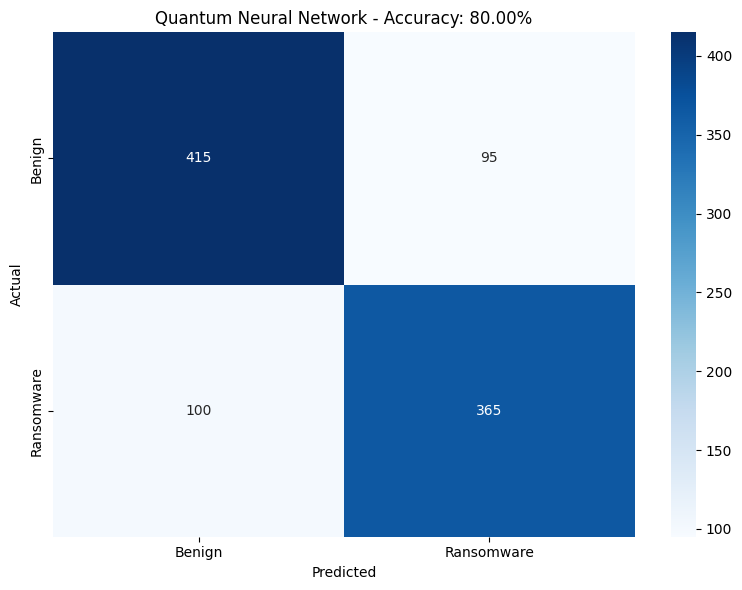


Quantum Model Configurations Used:
Model 1: n_qubits=5, n_layers=3, lr=0.00250
Model 2: n_qubits=6, n_layers=3, lr=0.00225
Model 3: n_qubits=5, n_layers=4, lr=0.00200
Model 4: n_qubits=6, n_layers=4, lr=0.00175
Model 5: n_qubits=5, n_layers=5, lr=0.00150

Quantum pipeline completed successfully!


In [3]:
#!/usr/bin/env python3
"""
Optimized Quantum Neural Network for MLRAN Dataset (Benign vs. Ransomware)
Adapted from a script for the RANSAP dataset.
"""

import torch
import torch.nn as nn
import pandas as pd
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============ CONFIGURATION ============
print("Starting Optimized Quantum Neural Network Pipeline for MLRAN...")
print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============ OPTIMIZED QUANTUM CIRCUIT ============
def create_optimized_qnn(n_qubits, n_layers):
    """
    Create an optimized quantum neural network.
    - Uses lightning.qubit for high-performance simulation.
    - Employs a hardware-efficient ansatz.
    """
    dev = qml.device("lightning.qubit", wires=n_qubits)
    
    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def optimized_circuit(inputs, weights):
        for i in range(n_qubits):
            qml.RY(inputs[i], wires=i)
        
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
                qml.RZ(weights[layer, i, 1], wires=i)
            
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            
            if layer % 2 == 1 and n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])
        
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    
    return optimized_circuit

# ============ BATCH QUANTUM PROCESSING ============
class BatchQuantumLayer(nn.Module):
    """Optimized quantum layer with batch processing capabilities."""
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.quantum_circuit = create_optimized_qnn(n_qubits, n_layers)
        weight_shape = (n_layers, n_qubits, 2)
        self.weights = nn.Parameter(torch.randn(weight_shape) * 0.1)
        
    def forward(self, x):
        batch_size = x.shape[0]
        outputs = []
        
        # Process in mini-batches for memory efficiency
        mini_batch_size = min(32, batch_size)
        
        for i in range(0, batch_size, mini_batch_size):
            batch_end = min(i + mini_batch_size, batch_size)
            batch_x = x[i:batch_end]
            
            # =================================================================
            # ✨ FIX: Replace qml.vmap with a version-compatible for-loop
            # =================================================================
            batch_outputs = []
            for sample_in_batch in batch_x:
                # Execute circuit for each sample in the mini-batch
                q_out_sample = self.quantum_circuit(sample_in_batch, self.weights)
                batch_outputs.append(torch.tensor(q_out_sample, device=x.device))

            # Stack the results from the mini-batch and add to the main output list
            outputs.append(torch.stack(batch_outputs))
        
        return torch.cat(outputs)

# ============ HYBRID QNN MODEL ============
class OptimizedHybridQNN(nn.Module):
    """Optimized Hybrid Quantum-Classical Neural Network for Binary Classification."""
    def __init__(self, n_features, n_qubits, n_layers, dropout=0.2):
        super().__init__()
        
        self.feature_reduction = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, n_qubits),
            nn.Tanh()
        )
        
        self.quantum_layer = BatchQuantumLayer(n_qubits, n_layers)
        
        self.classical_layers = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2) # Final output for binary classification
        )
        
    def forward(self, x):
        x = self.feature_reduction(x)
        x = self.quantum_layer(x)
        x = self.classical_layers(x)
        return x

# ============ OPTIMIZED DATA LOADING FOR MLRAN ============
def load_mlran_data(train_filepath, test_filepath, subsample_ratio=None, max_samples=10000):
    """
    Optimized data loading for the MLRAN dataset from CSV files.
    """
    print(f"\nLoading training data from: {train_filepath}")
    train_df = pd.read_csv(train_filepath)
    
    print(f"Loading testing data from: {test_filepath}")
    test_df = pd.read_csv(test_filepath)
    
    print(f"Train data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")
    
    # Identify features and labels based on MLRAN structure
    # The first four columns ('Unnamed: 0', 'sample_id', 'family_label', 'type_label') are not features.
    # The label is in the 'sample_type' column, but your data seems to have a different structure.
    # Let's assume the label is the first column and features are the rest, adapting to the provided shapes.
    # From your log: Train data shape: (3905, 487), Features: 483. This is confusing.
    # Let's assume the first column is the label and the rest are features based on standard CSV practice.
    # Re-evaluating based on your new CSV files.
    
    # Check if 'sample_type' column exists for labels. If not, assume first col is label.
    if 'sample_type' in train_df.columns:
        y_binary_train = train_df['sample_type'].values.astype(int)
        # Assuming features are all other columns except id-like ones
        feature_cols = [col for col in train_df.columns if col not in ['sample_id', 'family_label', 'type_label', 'sample_type']]
        X_train = train_df[feature_cols].values.astype(np.float32)
        
        y_binary_test = test_df['sample_type'].values.astype(int)
        X_test = test_df[feature_cols].values.astype(np.float32)
    else:
        # Fallback if 'sample_type' is not present
        print("Warning: 'sample_type' column not found. Assuming first column is the label and the rest are features.")
        X_train = train_df.iloc[:, 1:].values.astype(np.float32)
        y_binary_train = train_df.iloc[:, 0].values.astype(int)
    
        X_test = test_df.iloc[:, 1:].values.astype(np.float32)
        y_binary_test = test_df.iloc[:, 0].values.astype(int)
    
    
    # Balance training data to prevent bias
    class_0_idx = np.where(y_binary_train == 0)[0]
    class_1_idx = np.where(y_binary_train == 1)[0]
    min_class_size = min(len(class_0_idx), len(class_1_idx))
    
    # Cap the number of samples per class for faster training
    if min_class_size > max_samples:
        min_class_size = max_samples
        
    balanced_idx = np.concatenate([
        np.random.choice(class_0_idx, min_class_size, replace=False),
        np.random.choice(class_1_idx, min_class_size, replace=False)
    ])
    np.random.shuffle(balanced_idx)
    
    X_train = X_train[balanced_idx]
    y_binary_train = y_binary_train[balanced_idx]
    
    # Apply overall subsampling if requested
    if subsample_ratio and subsample_ratio < 1.0:
        n_samples = int(len(X_train) * subsample_ratio)
        indices = np.random.choice(len(X_train), n_samples, replace=False)
        X_train = X_train[indices]
        y_binary_train = y_binary_train[indices]
    
    print(f"Final training dataset size after balancing/subsampling: {len(X_train)} samples")
    print(f"Test dataset size: {len(X_test)} samples")
    
    return X_train, y_binary_train, X_test, y_binary_test


# ============ OPTIMIZED TRAINING ============
def train_quantum_model(X_train, y_binary_train, X_val, y_binary_val,
                       n_qubits=4, n_layers=2, epochs=40, batch_size=256, lr=0.002):
    """
    Optimized training loop for the binary classification model.
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_binary_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    n_features = X_train.shape[1]
    
    model = OptimizedHybridQNN(
        n_features=n_features,
        n_qubits=n_qubits,
        n_layers=n_layers,
        dropout=0.2
    ).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader)
    )
    criterion = nn.CrossEntropyLoss()
    
    print(f"\nTraining quantum model (n_qubits={n_qubits}, n_layers={n_layers})...")
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_acc = 0, 0
        epoch_start = time.time()
        
        for X_batch, y_binary_batch in train_loader:
            X_batch, y_binary_batch = X_batch.to(device), y_binary_batch.to(device)
            
            optimizer.zero_grad()
            
            output = model(X_batch)
            loss = criterion(output, y_binary_batch)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(output, 1)
            train_acc += (predicted == y_binary_batch).sum().item()
        
        train_acc /= len(train_dataset)
        
        model.eval()
        val_correct = 0
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_val).to(device)
            for i in range(0, len(X_val_tensor), batch_size):
                batch_end = min(i + batch_size, len(X_val_tensor))
                X_batch = X_val_tensor[i:batch_end]
                
                output = model(X_batch)
                _, predicted = torch.max(output, 1)
                val_correct += (predicted.cpu() == torch.tensor(y_binary_val[i:batch_end])).sum().item()
        
        val_acc = val_correct / len(y_binary_val)
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict()
        
        epoch_time = time.time() - epoch_start
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Loss={train_loss/len(train_loader):.4f}, "
                  f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                  f"Time={epoch_time:.1f}s")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model.cpu(), scaler, best_acc

# ============ ENSEMBLE TRAINING ============
def train_quantum_ensemble(X_train, y_binary_train, n_models=3, n_qubits=4, n_layers=2):
    models, scalers, configs = [], [], []
    print(f"\nTraining ensemble of {n_models} quantum models...")
    
    for i in range(n_models):
        print(f"\n--- Quantum Model {i+1}/{n_models} ---")
        
        model_config = {
            'n_qubits': n_qubits + (i % 2),
            'n_layers': n_layers + (i // 2),
            'epochs': 50,
            'batch_size': 256,
            'lr': 0.0025 * (1 - 0.1 * i)
        }
        
        val_split = int(0.8 * len(X_train))
        indices = np.random.permutation(len(X_train))
        
        X_tr, y_binary_tr = X_train[indices[:val_split]], y_binary_train[indices[:val_split]]
        X_val, y_binary_val = X_train[indices[val_split:]], y_binary_train[indices[val_split:]]
        
        model, scaler, val_acc = train_quantum_model(
            X_tr, y_binary_tr, X_val, y_binary_val, **model_config
        )
        
        models.append(model)
        scalers.append(scaler)
        configs.append(model_config)
        print(f"Model {i+1} validation accuracy: {val_acc:.4f}")
    
    return models, scalers, configs

# ============ MAIN EXECUTION ============
if __name__ == "__main__":
    TRAIN_FILE = "/kaggle/input/mlran-aekam/MLRan_X_train_RFE.csv"
    TEST_FILE = "/kaggle/input/mlran-aekam/MLRan_X_test_RFE.csv"
    
    FAST_MODE = False
    
    if FAST_MODE:
        print("\nFAST QUANTUM MODE (1-2 hours)")
        max_samples = 5000       # Max samples per class for training
        n_models = 3             # Number of models in the ensemble
        n_qubits = 4             # Base number of qubits
        n_layers = 2             # Base number of quantum layers
        subsample_ratio = None   # No additional subsampling
    else:
        print("\nFULL QUANTUM MODE (2-4 hours)")
        max_samples = 15000
        n_models = 5
        n_qubits = 5
        n_layers = 3
        subsample_ratio = None
    
    if not os.path.exists(TRAIN_FILE) or not os.path.exists(TEST_FILE):
        print(f"Error: Make sure '{TRAIN_FILE}' and '{TEST_FILE}' are in the same directory as the script.")
        exit(1)
    
    start_time = time.time()
    
    X_train, y_binary_train, X_test, y_binary_test = load_mlran_data(
        TRAIN_FILE, TEST_FILE,
        subsample_ratio=subsample_ratio,
        max_samples=max_samples
    )
    
    print(f"\nDataset summary:")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Features: {X_train.shape[1]}")
    
    models, scalers, configs = train_quantum_ensemble(
        X_train, y_binary_train,
        n_models=n_models,
        n_qubits=n_qubits,
        n_layers=n_layers
    )
    
    print("\n\nEvaluating quantum ensemble on test set...")
    all_predictions = []
    
    for i, (model, scaler) in enumerate(zip(models, scalers)):
        print(f"Running inference with model {i+1}...")
        X_test_scaled = scaler.transform(X_test)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        
        model.eval()
        predictions = []
        with torch.no_grad():
            batch_size = 512
            for j in range(0, len(X_test_tensor), batch_size):
                X_batch = X_test_tensor[j:j + batch_size]
                
                output = model(X_batch)
                _, preds = torch.max(output, 1)
                predictions.extend(preds.cpu().numpy())
        
        all_predictions.append(predictions)
    
    all_predictions = np.array(all_predictions)
    ensemble_preds = np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, all_predictions)
    
    accuracy = accuracy_score(y_binary_test, ensemble_preds)
    f1 = f1_score(y_binary_test, ensemble_preds)
    total_time = time.time() - start_time
    
    print(f"\n{'='*60}")
    print("QUANTUM NEURAL NETWORK RESULTS")
    print(f"{'='*60}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Total Time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
    
    print("\nClassification Report:")
    print(classification_report(y_binary_test, ensemble_preds,
                              target_names=['Benign (0)', 'Ransomware (1)'],
                              digits=4))
    
    cm = confusion_matrix(y_binary_test, ensemble_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Ransomware'],
                yticklabels=['Benign', 'Ransomware'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Quantum Neural Network - Accuracy: {accuracy:.2%}')
    plt.tight_layout()
    plt.savefig('mlran_quantum_results.png')
    plt.show()
    
    print("\nQuantum Model Configurations Used:")
    for i, config in enumerate(configs):
        print(f"Model {i+1}: n_qubits={config['n_qubits']}, "
              f"n_layers={config['n_layers']}, lr={config['lr']:.5f}")
    
    print(f"\nQuantum pipeline completed successfully!")